In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf

In [2]:
print(os.listdir("C:/Users/ASUS/Downloads/FER"))

['test', 'train']


In [3]:
train_path = "C:/Users/ASUS/Downloads/FER/train"
val_path = "C:/Users/ASUS/Downloads/FER/test"

In [4]:
# Importing TensorFlow libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras import Sequential
from tensorflow import keras
from sklearn.model_selection import KFold

In [5]:
emotion_labels = sorted(os.listdir(train_path))
print(emotion_labels)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
batch_size = 64
target_size = (48,48)

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=target_size,
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode='categorical',
        shuffle=True)

val_generator = val_datagen.flow_from_directory(
        val_path,
        target_size=target_size,
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [7]:
input_shape = (48,48,1) # img_rows, img_colums, color_channels
num_classes = 7

In [8]:
print(os.listdir("C:/Users/ASUS/Downloads/FER/train"))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
def plot_images(img_dir, top=10):
    all_img_dirs = os.listdir(img_dir)
    img_files = [os.path.join(img_dir, file) for file in all_img_dirs][:5]
  
    plt.figure(figsize=(12, 12))
  
    for idx, img_path in enumerate(img_files):
        plt.subplot(5, 5, idx+1)
        img = plt.imread(img_path)
        plt.tight_layout()         
        plt.imshow(img, cmap='gray')

Angry: 



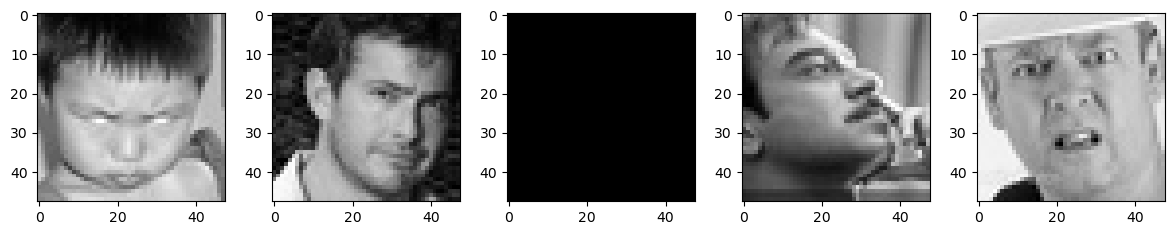

In [10]:
print('Angry: ')
print()
plot_images(train_path+'/angry')

Disgust: 



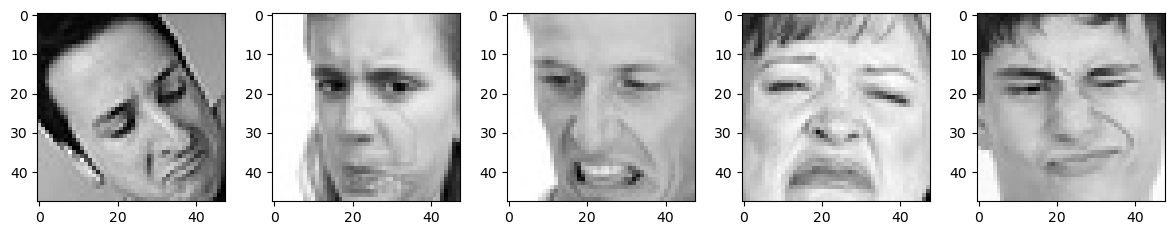

In [11]:
print('Disgust: ')
print()
plot_images(train_path+'/disgust')

Fear: 



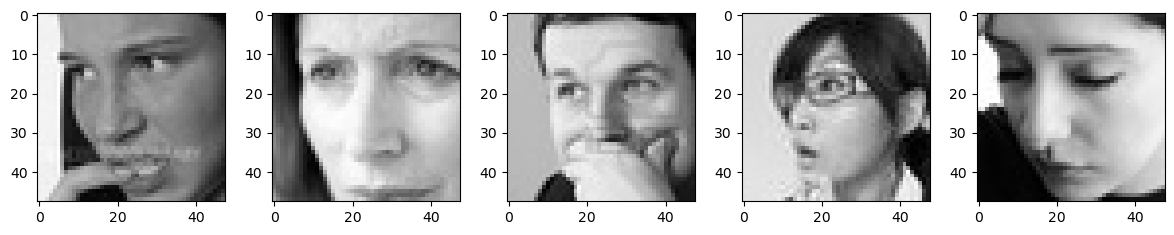

In [12]:
print('Fear: ')
print()
plot_images(train_path+'/fear')

Happy: 



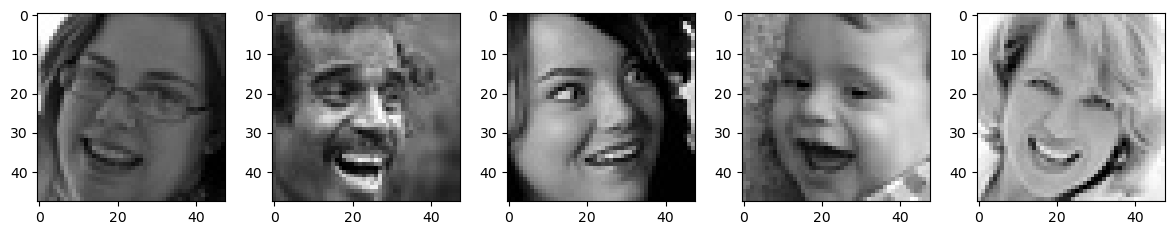

In [13]:
print('Happy: ')
print()
plot_images(train_path+'/happy')

Neutral: 



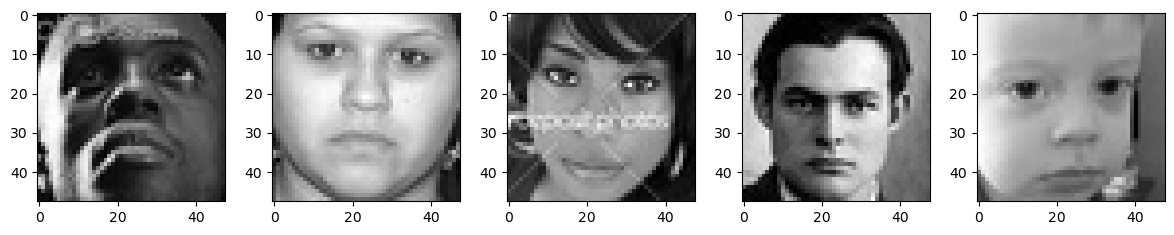

In [14]:
print('Neutral: ')
print()
plot_images(train_path+'/neutral')

Sad: 



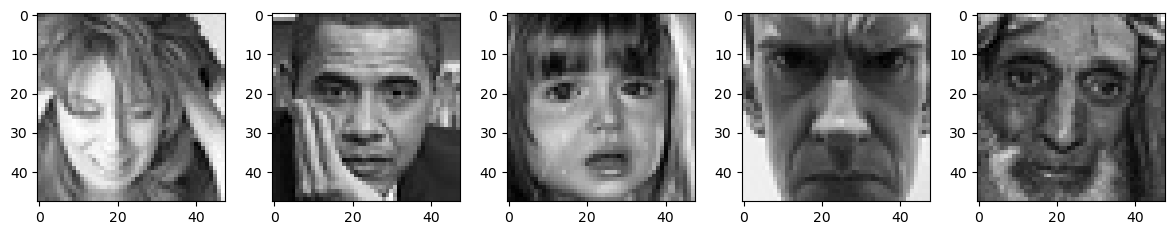

In [15]:
print('Sad: ')
print()
plot_images(train_path+'/sad')

Surprise: 



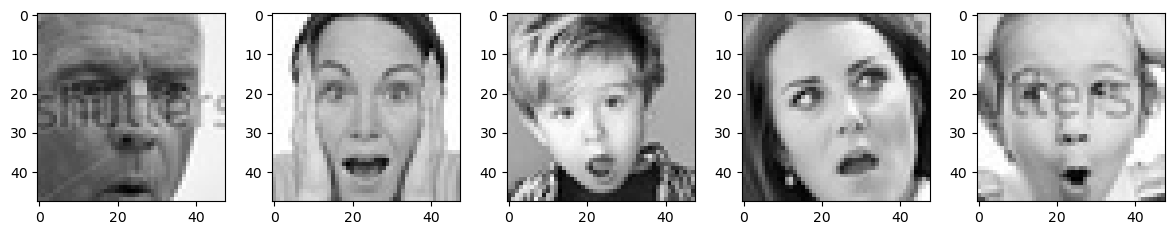

In [16]:
print('Surprise: ')
print()
plot_images(train_path+'/surprise')

In [17]:
emotions = os.listdir("C:/Users/ASUS/Downloads/FER/train")
for emotion in emotions:
    count = len(os.listdir(f'C:/Users/ASUS/Downloads/FER/train/{emotion}'))
    print(f'{emotion} faces={count}')

angry faces=3995
disgust faces=436
fear faces=4097
happy faces=7215
neutral faces=4965
sad faces=4830
surprise faces=3171


In [18]:
emotions = os.listdir("C:/Users/ASUS/Downloads/FER/test")
for emotion in emotions:
    count = len(os.listdir(f'C:/Users/ASUS/Downloads/FER/test/{emotion}'))
    print(f'{emotion} faces={count}')

angry faces=958
disgust faces=111
fear faces=1024
happy faces=1774
neutral faces=1233
sad faces=1247
surprise faces=831


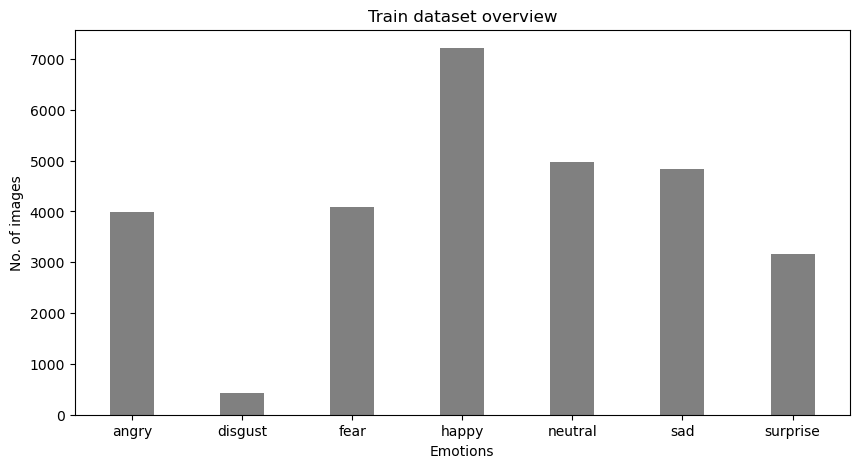

In [19]:
emotions = os.listdir("C:/Users/ASUS/Downloads/FER/train")
values = [len(os.listdir(f'C:/Users/ASUS/Downloads/FER/train/{emotion}')) for emotion in emotions]
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(emotions, values, color ='grey',
        width = 0.4)

plt.xlabel("Emotions")
plt.ylabel("No. of images")
plt.title("Train dataset overview")
plt.show()

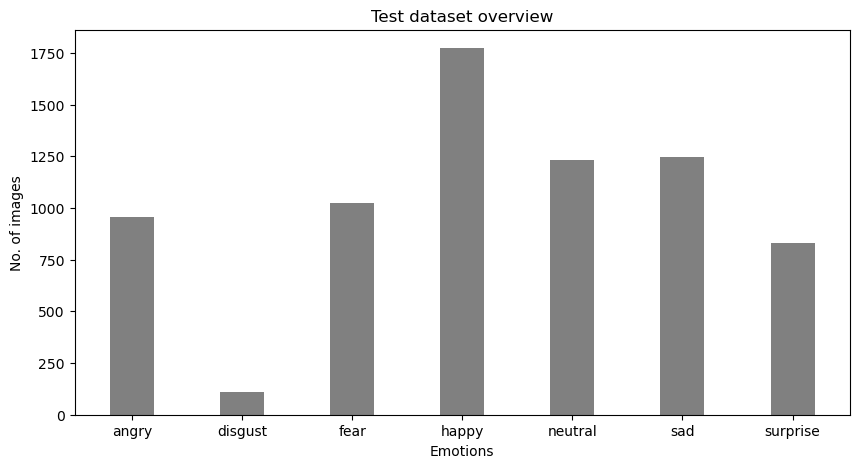

In [20]:
emotions = os.listdir("C:/Users/ASUS/Downloads/FER/test")
values = [len(os.listdir(f'C:/Users/ASUS/Downloads/FER/test/{emotion}')) for emotion in emotions]
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(emotions, values, color ='grey',
        width = 0.4)

plt.xlabel("Emotions")
plt.ylabel("No. of images")
plt.title("Test dataset overview")
plt.show()

In [21]:
num_epochs = 200
number_of_classes = 7
model = Sequential()
model.add(layers.Conv2D(filters = 32, padding = "same",activation = "relu",kernel_size=3, strides = 2,input_shape=input_shape))
model.add(layers.MaxPool2D(pool_size=(2,2),strides = 2))

model.add(layers.Conv2D(filters = 32, padding = "same",activation = "relu",kernel_size=3))
model.add(layers.MaxPool2D(pool_size=(2,2),strides = 2))

model.add(layers.Flatten())
model.add(layers.Dense(128,activation="relu"))

#Output layer
model.add(layers.Dense(1,kernel_regularizer=regularizers.l2(0.01),activation = "linear"))

In [22]:
model.add(layers.Dense(number_of_classes,kernel_regularizer = regularizers.l2(0.01),activation= "softmax"))
model.compile(optimizer="adam",loss="squared_hinge", metrics = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1152)              0         
                                                                 
 dense (Dense)               (None, 128)               1

In [23]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VAL   = val_generator.n//val_generator.batch_size

In [24]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VAL   = val_generator.n//val_generator.batch_size
history = model.fit(x=train_generator, steps_per_epoch=STEP_SIZE_TRAIN, epochs=num_epochs, batch_size=batch_size, validation_data=val_generator, validation_steps=STEP_SIZE_VAL)

Epoch 1/200
448/448 [==============================] - 51s 109ms/step - loss: 1.2196 - accuracy: 0.2104 - val_loss: 1.2115 - val_accuracy: 0.2467
Epoch 2/200
448/448 [==============================] - 28s 62ms/step - loss: 1.2086 - accuracy: 0.2516 - val_loss: 1.2046 - val_accuracy: 0.2736
Epoch 3/200
448/448 [==============================] - 27s 60ms/step - loss: 1.1953 - accuracy: 0.2907 - val_loss: 1.1856 - val_accuracy: 0.3069
Epoch 4/200
448/448 [==============================] - 27s 59ms/step - loss: 1.1845 - accuracy: 0.3097 - val_loss: 1.1788 - val_accuracy: 0.3260
Epoch 5/200
448/448 [==============================] - 27s 60ms/step - loss: 1.1774 - accuracy: 0.3307 - val_loss: 1.1720 - val_accuracy: 0.3477
Epoch 6/200
448/448 [==============================] - 28s 63ms/step - loss: 1.1721 - accuracy: 0.3479 - val_loss: 1.1670 - val_accuracy: 0.3574
Epoch 7/200
448/448 [==============================] - 27s 61ms/step - loss: 1.1683 - accuracy: 0.3556 - val_loss: 1.1638 - val_a

In [31]:
models.save_model(model, 'C:/Users/ASUS/Downloads/CNN1.h5')

In [32]:
model2=models.load_model('C:/Users/ASUS/Downloads/CNN1.h5')
model2.evaluate(val_generator,steps=STEP_SIZE_VAL)

112/112 [==============================] - 2s 19ms/step - loss: 1.1700 - accuracy: 0.4234


[1.1699713468551636, 0.4234096109867096]

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


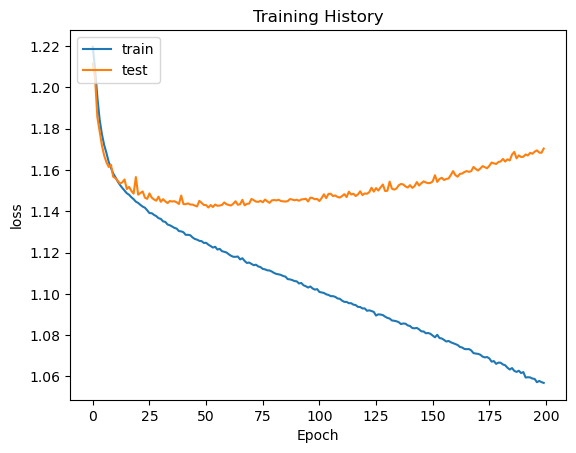

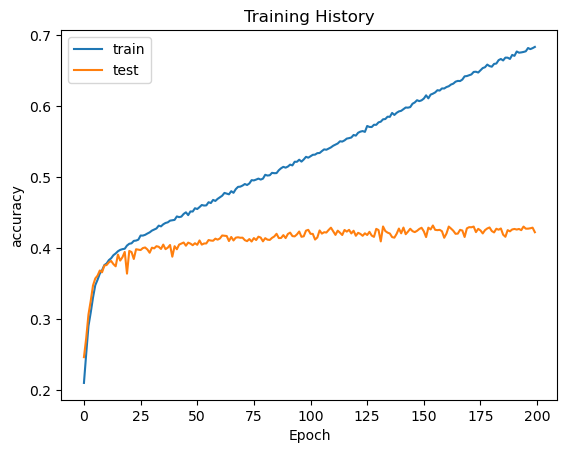

In [33]:
keys=history.history.keys()
print(keys)

def show_train_history(hisData,train,test): 
    plt.plot(hisData.history[train])
    plt.plot(hisData.history[test])
    plt.title('Training History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

show_train_history(history, 'loss', 'val_loss')
show_train_history(history, 'accuracy', 'val_accuracy')

In [34]:
val_generator.reset()
pred=model2.predict_generator(val_generator,steps=STEP_SIZE_VAL,verbose=1)

  4/112 [>.............................] - ETA: 2s

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9436\3632774363.py:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  pred=model2.predict_generator(val_generator,steps=STEP_SIZE_VAL,verbose=1)


112/112 [==============================] - 2s 19ms/step


In [35]:
predicted_class_indices=np.argmax(pred,axis=1)

In [36]:
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]

In [48]:
# Python program to translate
# speech to text and text to speech
import speech_recognition as sr
import pyttsx3
import webbrowser  

# Initialize the recognizer
r = sr.Recognizer()

# Function to convert text to speech
def ask():
    engine = pyttsx3.init()
    engine.say("How are you feeling today")
    engine.runAndWait()
    
def SpeakText(command):

    # Initialize the engine
    engine = pyttsx3.init()
    engine.say("You seem to be"+command)
    engine.say("Let me play you some interesting music to refresh your mood")
    if(command=="angry" or command=="disgust" or command=="fear" or command=="surprise"):
        url= 'https://open.spotify.com/playlist/42rb18eADeFy3ywruwwG3i' 
        webbrowser.open_new_tab(url) 
    elif(command=="sad"):
        url= 'https://open.spotify.com/playlist/7r1ijsHcbL1dLcLFtnNRmi' 
        webbrowser.open_new_tab(url) 
    elif(command=="happy" or command=="neutral"):
        url= 'https://open.spotify.com/playlist/47X8CcLloML4Fz5Vq9trYL' 
        webbrowser.open_new_tab(url) 
    engine.runAndWait()

In [49]:
def speechtotext():
    q=0
    while(q!=1):

        # Exception handling to handle
        # exceptions at the runtime
        try:
            ask()
            # use the microphone as source for input.
            with sr.Microphone() as source2:
                # wait for a second to let the recognizer
                # adjust the energy threshold based on
                # the surrounding noise level
                r.adjust_for_ambient_noise(source2, duration=0.2)
                #listens for the user's input
                audio2 = r.listen(source2)
                #print("How are you feeling today ?")
                # Using google to recognize audio
                MyText = r.recognize_google(audio2)
                MyText = MyText.lower()

                #print(MyText)
                q=1
                SpeakText(MyText)
                return MyText

        except sr.RequestError as e:
            print("Could not request results; {0}".format(e))

        except sr.UnknownValueError:
            print("unknown error occurred")
            q=1

In [50]:
def image():
    import cv2 as cv
    cam_port = 0
    cam = cv.VideoCapture(cam_port)
    result, image = cam.read()
    if result:
        cv.imwrite("C:/Users/ASUS/Downloads/image2/image.jpg", image)
        cv.waitKey(0)
    else:
        print("No image detected. Please! try again")
    cam.release()
    cv.destroyAllWindows()
    import cv2

    # Read the input image
    img = cv2.imread("C:/Users/ASUS/Downloads/image2/image.jpg")

    # Convert into grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Load the cascade
    face_cascade=cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml") #Note the change 
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    # Draw rectangle around the faces and crop the faces
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
        faces = img[y:y + h, x:x + w]
        cv2.imshow("face",faces)
        cv2.imwrite("C:/Users/ASUS/Downloads/images/abc/face1.jpg", faces)

    # Display the output
    #cv2.imwrite('detcted.jpg', img)
    #cv2.imshow('img', img)
    cv2.waitKey()
    from PIL import Image,ImageOps
    im = Image.open(r"C:/Users/ASUS/Downloads/images/abc/face1.jpg")
    im2=ImageOps.grayscale(im)
    im2.save("C:/Users/ASUS/Downloads/images/abc/face1.jpg")
    im2.show()
    model2=models.load_model('C:/Users/ASUS/Downloads/CNN1.h5')
    path = "C:/Users/ASUS/Downloads/images"
    datagen = ImageDataGenerator(rescale=1./255)
    generator = datagen.flow_from_directory(
            path,
            target_size=target_size,
            batch_size=1,
            color_mode="grayscale",
            class_mode='categorical',
            shuffle=True)
    cnn = model2.predict(generator, steps=1)
    predicted_class_indices=np.argmax(cnn,axis=1)
    labels = (train_generator.class_indices)
    labels = dict((v,k) for k,v in labels.items())
    predictions1 = [labels[k] for k in predicted_class_indices]
    print("Emotion:",predictions1[0])
    SpeakText(predictions1[0])
    #os.remove("C:/Users/ASUS/Downloads/images/abc/face1.jpg")

In [51]:
print("Press 1:To Interact with model using voice \n")
print("Press 2:To Interact with model with facial emotion recognition \n")
i=int(input("Enter your choice"))
if(i==1):
    r=speechtotext()
    print(r)
elif(i==2):
    image()

Press 1:To Interact with model using voice 

Press 2:To Interact with model with facial emotion recognition 

Enter your choice2
Found 1 images belonging to 1 classes.
1/1 [==============================] - 0s 62ms/step
Emotion: neutral
